In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))


from src.outras import baixar_arquivo

url = "https://raw.githubusercontent.com/chrisdmell/DataScience/refs/heads/master/data_dump/01_cipla_ds_challenge/train.csv"
pasta = '../data'
nome_csv = "train.csv"
baixar_arquivo(url,pasta,nome_csv)

Iniciando download de: train.csv...
✅ Sucesso! Arquivo salvo em: ..\data\train.csv


In [2]:
import pandas as pd

df = pd.read_csv("../data/train.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer ID                  30000 non-null  object 
 1   Name                         30000 non-null  object 
 2   Gender                       29947 non-null  object 
 3   Age                          30000 non-null  int64  
 4   Income (USD)                 25424 non-null  float64
 5   Income Stability             28317 non-null  object 
 6   Profession                   30000 non-null  object 
 7   Type of Employment           22730 non-null  object 
 8   Location                     30000 non-null  object 
 9   Loan Amount Request (USD)    30000 non-null  float64
 10  Current Loan Expenses (USD)  29828 non-null  float64
 11  Expense Type 1               30000 non-null  object 
 12  Expense Type 2               30000 non-null  object 
 13  Dependents      

* <b>Customer ID</b>: identificação única - Descartar
* <b>Name</b>: Nome do cliente - Descartar
* <b>Gender</b>: Gênero - converter para string - Valores faltantes
* <b>Age</b>: Idade - ok
* <b>Income (USD)</b>: Renda - estudar distribuição da renda - 5 mil valores faltantes - converter para float - decidir
* <b>Income Stability</b>: Estabilidade da Renda - 1683 mil valores faltantes - alta/baixa - converter string
* <b>Profession</b>: Profissão - converter object para string
* <b>Type of employment</b>: Tipo de emprego - 7 mil dados faltantes - converter para string - correlaciona-se com o tipo de emprego
* <b>Location</b>: Localização atual de residência - 0 dados faltantes - Explorar
* <b>Loan Amount Request (USD)</b>: quantia emprestimo solicitada
* <b>Current Loan Expenses (USD)</b>: Despesa mensal de emprestimo - valores negativos, limpar - de float para int
* <b>Expense Type 1</b>: tipo Despesa mensal do cliente - binario - 0 valores faltantes
* <b>Expense Type 2</b>: tipo Despesa mensal do cliente - binario - 0 valores faltantes
* <b>Dependents</b>: dependentes - cônjuje/pais/irmão/filhos - numero - não continuo - analisar
* <b>Credit Score</b>: Pontuação de credito - normalmente distribuida. converter para int
* <b>No. of Defaults</b>: Número de inadimplencias - emprestimos ou EMI - indicador SIM/NÂO
* <b>HAS active Credit Card</b>: Possui cartão de credito ativo - categórico
* <b>Property ID</b>: Identificação da propriedade - descartar
* <b>Property Age</b>: Idade da propriedade - Possui outliers - 5 mil dados faltantes
* <b>Property Type</b>: Tipo da propriedade - 4 tipos de propriedades
* <b>Property Location</b>: Localização da propriedade - categórico
* <b>Co-applicant</b>: co-requerente - categórico, valores negativos a serem limpos
* <b>Property price</b>: Preço da Propriedade - negativos a serem convertidos para 0
* <b>Loan Sanction Amount (USD)</b>: Valor de empréstimo aprovado! - classe




## Processamento de Dados


In [4]:
# Importação de Bibliotecas
import numpy as np


#### Descarte de Colunas Irrelevantes


In [5]:
df.drop(['Customer ID', 'Name', 'Property ID'], axis=1, inplace=True)

#### Converter Tipos de dados

In [28]:
from src.data_clear import converter_type

converter_type(df, "Gender", 'string')
converter_type(df, 'Income Stability', 'string')
converter_type(df, 'Profession', 'string')
converter_type(df, 'Type of Employment', 'string')

##
# df['Gender'] = df['Gender'].astype('string')
# df['Income Stability'] = df['Income Stability'].astype('string')
# df['Profession'] = df['Profession'].astype('string')
# df['Type of Employment'] = df['Type of Employment'].astype('string')
# df['Credit Score'] = df['Credit Score'].fillna(0).astype('int') # Solução converter os valores faltantes com 0 e depois converter


o atributo Gender foi convertido para string
o atributo Income Stability foi convertido para string
o atributo Profession foi convertido para string
o atributo Type of Employment foi convertido para string


#### Tratamento de valores faltantes

In [ ]:
# converter_type(df,"Income (USD)", "float")

: 

: 

: 

: 

: 

: 

: 

In [7]:
from src.data_clear import valores_faltantes

# print(round(df['Income (USD)'].median()))
# print(df['Income (USD)'].median())
print(df['Income (USD)'].dtype)


valores_faltantes(df, "Income (USD)", 'median' )

float64
O atributo Income (USD) teve nulos ou faltantes substituidos por median: 2222.435


In [8]:
employment_mode = df['Type of Employment'].mode()[0]
valores_faltantes(df,"Type of Employment",'mode')

O atributo Type of Employment teve nulos ou faltantes substituidos por mode: 0    Laborers
Name: Type of Employment, dtype: string


In [9]:
# Genero os valores faltantes serão substituido pela moda, o valor que mais se repete.

genero = df['Gender'].value_counts()
print(genero)

df["Gender"].fillna('M', inplace=True)
print(genero)


Gender
M    15053
F    14894
Name: count, dtype: Int64
Gender
M    15053
F    14894
Name: count, dtype: Int64


C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\3004338478.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna('M', inplace=True)


In [10]:
# Os valores faltantes serão subtituidos pela moda
val_branco = df["Income Stability"].value_counts(dropna=False)
percentual = (val_branco / len(df['Income Stability'])) *100
print(f'{percentual}') 
df['Income Stability'].fillna("Low", inplace=True)
percentual_atual = df['Income Stability'].value_counts()
print(f'{percentual_atual}') 

Income Stability
Low     85.836667
High     8.553333
<NA>         5.61
Name: count, dtype: Float64
Income Stability
Low     27434
High     2566
Name: count, dtype: Int64


C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\851652968.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income Stability'].fillna("Low", inplace=True)


In [11]:
dependentes = df['Dependents'].value_counts(dropna=False)
# valores_faltantes(df, "Dependents", 'mode')
df['Dependents'].fillna(2.0, inplace=True)
dependentes

C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\1554181292.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(2.0, inplace=True)


Dependents
2.0     13108
3.0      5719
1.0      5544
4.0      2704
NaN      2493
5.0       372
6.0        50
7.0         7
8.0         1
10.0        1
14.0        1
Name: count, dtype: int64

In [12]:
media = df['Credit Score'].median()
# media
branco = df["Credit Score"].isna().sum()
print(f"antes do tratamento {branco}")
df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)
branco = df["Credit Score"].isna().sum()
print(f"Depois do tratamento {branco}")

antes do tratamento 1703
Depois do tratamento 0


C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\2490404592.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)


In [13]:
df["Property Location"].fillna('Unknown', inplace=True)


C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\3522372100.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Property Location"].fillna('Unknown', inplace=True)


#### Limpeza de dados inconsistentes

In [14]:
# Corrigir valores negativos para "Current Loan Expenses (USD)" e "Property Price"
df['Current Loan Expenses (USD)'] = df['Current Loan Expenses (USD)'].apply(lambda x: abs(x))
df['Property Price'] = df["Property Price"].apply(lambda x: max(x, 0))

In [15]:
# Convertendo "Co-applicant" para uma categoria binária, assumindo que valores negativos são erros
df["Co-Applicant"] = df["Co-Applicant"].apply(lambda x: 1 if x > 0 else 0)

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gera Estatistica descritiva
print(df.describe())

                Age  Income (USD)  Loan Amount Request (USD)  \
count  30000.000000  3.000000e+04               30000.000000   
mean      40.092300  2.568320e+03               88826.333855   
std       16.045129  1.036924e+04               59536.949605   
min       18.000000  3.777000e+02                6048.240000   
25%       25.000000  1.743305e+03               41177.755000   
50%       40.000000  2.222435e+03               75128.075000   
75%       55.000000  2.869142e+03              119964.605000   
max       65.000000  1.777460e+06              621497.820000   

       Current Loan Expenses (USD)    Dependents  Credit Score  \
count                 29828.000000  30000.000000  30000.000000   
mean                    412.793052      2.232000    739.881670   
std                     221.766117      0.913457     70.085603   
min                      33.760000      1.000000    580.000000   
25%                     251.280000      2.000000    685.415000   
50%                     377

#### Verificação de correlação entre as variáveis

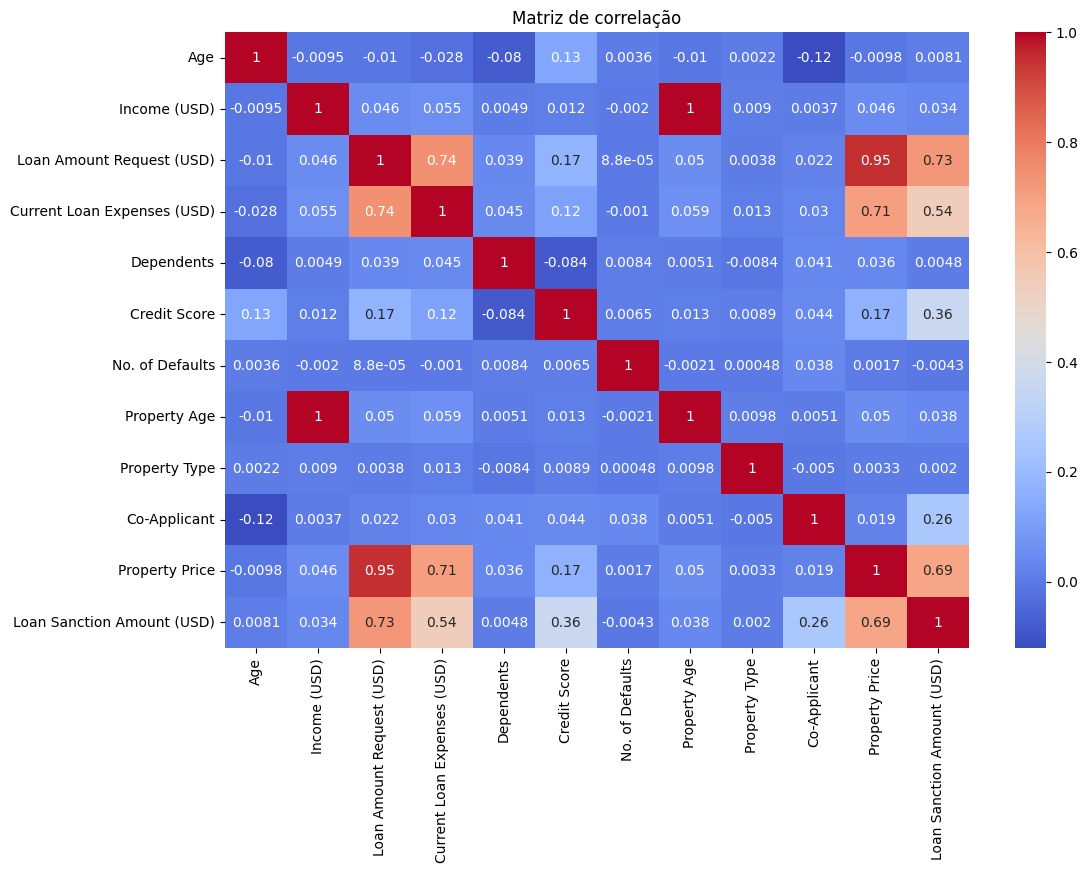

In [17]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de correlação")
plt.show()

#### Histograma

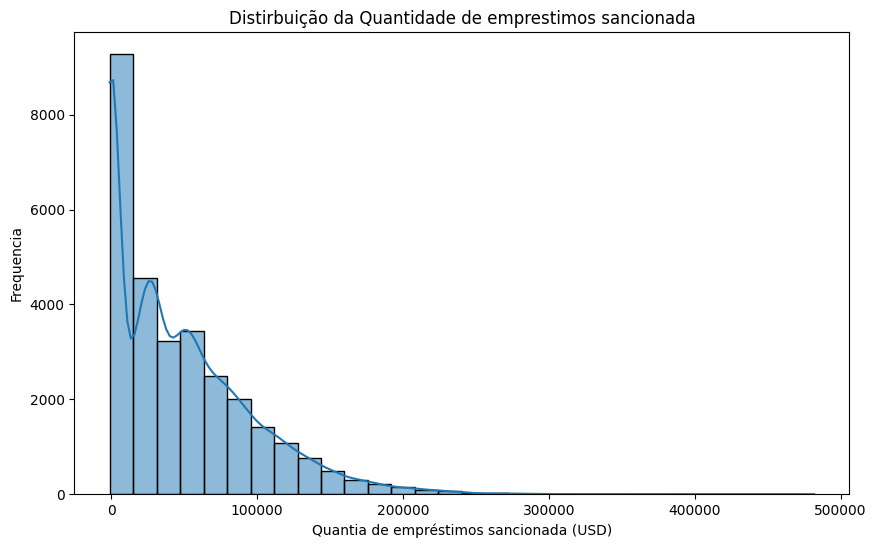

In [18]:
# histograma para a distribuição da variável de interesse, exemplo "Loan Sanction Amount (USD)"
plt.figure(figsize=(10,6))
sns.histplot(df['Loan Sanction Amount (USD)'], bins=30, kde=True)
plt.title("Distirbuição da Quantidade de emprestimos sancionada")
plt.xlabel("Quantia de empréstimos sancionada (USD)")
plt.ylabel("Frequencia")
plt.show()

C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\4208734411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Loan Sanction Amount (USD)'], showmeans=True, palette="Set2")


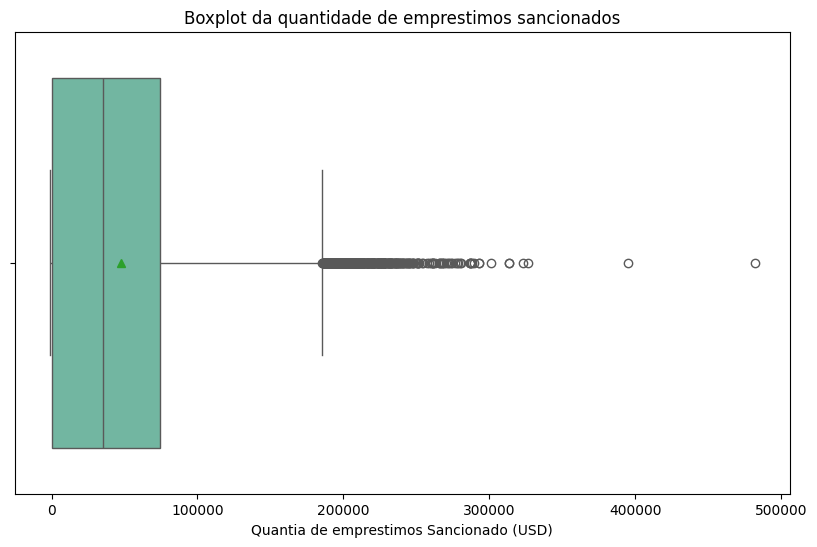

In [19]:
# Boxplot para verificar a presença de outliers
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Loan Sanction Amount (USD)'], showmeans=True, palette="Set2")
plt.title("Boxplot da quantidade de emprestimos sancionados")
plt.xlabel("Quantia de emprestimos Sancionado (USD)")
plt.show()

In [20]:
#Tratamento valores negativos para "Loan Sanction Amount (USD)"
# df['Loan Sanction Amount (USD)'] = df['Loan Sanction Amount (USD)'].apply(lambda x: max(x,0))
df['Loan Sanction Amount (USD)'] = df['Loan Sanction Amount (USD)'].clip(lower=0) # subtitui tudo abaixo de 0 por 0, mais rapido que o lambda

In [21]:
#Investiga e trata outliers para "income (USD)" e "Property Age"
#Pode-se usar a técnica por IQR ou Z-score para identificar e tratar outliers
Q1 = df['Income (USD)'].quantile(0.25)
Q3 = df['Income (USD)'].quantile(0.75)
IQR = Q3 - Q1
income_outlier_condition = ~df["Income (USD)"].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
df.loc[income_outlier_condition, "Income (USD)"] = np.nan
df['Income (USD)'].fillna(df['Income (USD)'].median(), inplace=True)

C:\Users\dyego\AppData\Local\Temp\ipykernel_23288\974797238.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income (USD)'].fillna(df['Income (USD)'].median(), inplace=True)


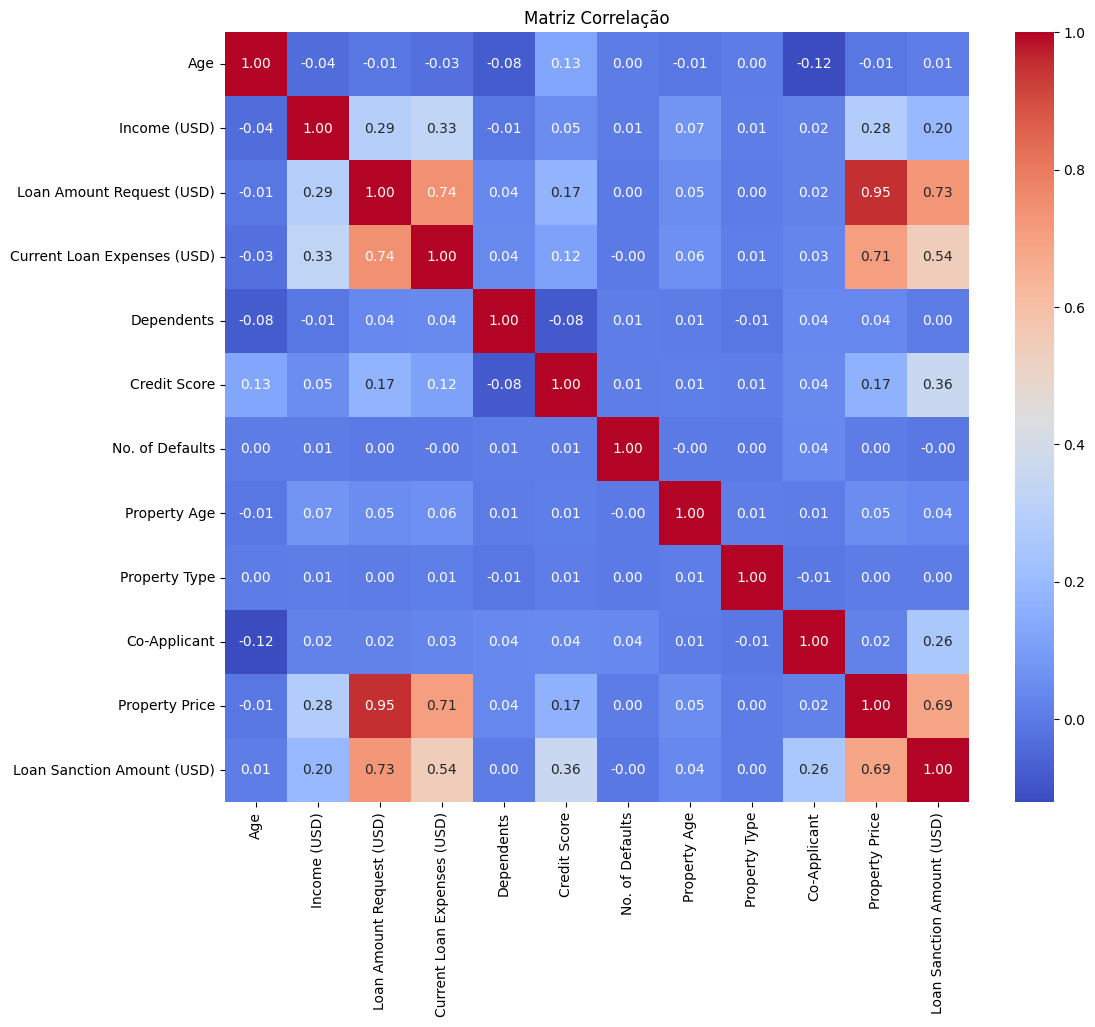

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matriz Correlação")
plt.show()




In [23]:
#Verificação de multicolinearidade usando VIF
# Assegura que o DataFrame só contém variáveis numericas
numeric_df = df.select_dtypes(include=[np.number])

In [24]:
# tratamento de valores ausentes e infinitos
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan) # susbtitui infinitos por NAN
numeric_df = numeric_df.dropna(axis=0) # Remove linhas NAN

In [25]:
# Recalcular VIF após tratamento de dados
vif_data = pd.DataFrame()
vif_data['Feature'] = numeric_df.columns
vif_data['VIF'] = [variance_inflation_factor(numeric_df.values, i) for i in range(numeric_df.shape[1])]
print(vif_data)

                        Feature        VIF
0                           Age   7.343468
1                  Income (USD)   9.343740
2     Loan Amount Request (USD)  41.689856
3   Current Loan Expenses (USD)  10.409351
4                    Dependents   6.545451
5                  Credit Score  28.453888
6               No. of Defaults   1.241127
7                  Property Age   1.060368
8                 Property Type   5.678771
9                  Co-Applicant   6.685137
10               Property Price  31.363473
11   Loan Sanction Amount (USD)   4.200198


In [29]:
# Usando o resultado de vif anterior para identificar columns com VIF > 11
high_vif_features = vif_data[vif_data['VIF'] > 11]['Feature'].tolist()

df_final = numeric_df.drop(columns=high_vif_features)

vif_data_update = pd.DataFrame()
vif_data_update['feature'] = df_final.columns
vif_data_update['VIF'] = [variance_inflation_factor(df_final.values, i) for i in range(df_final.shape[1])]

print(vif_data_update)
print(df_final)



                       feature       VIF
0                          Age  5.331767
1                 Income (USD)  8.079621
2  Current Loan Expenses (USD)  6.631104
3                   Dependents  5.660692
4              No. of Defaults  1.237121
5                 Property Age  1.060272
6                Property Type  5.039375
7                 Co-Applicant  5.545658
8   Loan Sanction Amount (USD)  2.824739
       Age  Income (USD)  Current Loan Expenses (USD)  Dependents  \
0       56      1933.050                       241.08         3.0   
1       32      2222.435                       495.81         1.0   
2       65       988.190                       171.95         1.0   
4       31      2614.770                       491.41         2.0   
5       60      1234.920                       181.48         2.0   
...    ...           ...                          ...         ...   
29994   39      2250.190                       430.66         3.0   
29995   38      2222.435              

## Modelagem Preditiva

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Defini as variáveis independente (x) e a variável dependente (y)
X= df_final.drop('Loan Sanction Amount (USD)', axis=1)
y= df_final['Loan Sanction Amount (USD)']

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Criar e treinar modelo de regressão

model = LinearRegression()
model.fit(X_train, y_train)

#Prever e avaliar modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f' MSE: {mse}')
print(f' R2: {r2}')




 MSE: 1527044044.5448587
 R2: 0.3361896238045391


In [33]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Normalizar os dados
scaler = StandardScaler()

# Definir os modelos validação cruzada
ridge_cv = RidgeCV(alphas=np.logspace(-6, 6, 13), cv=5)
lasso_cv = LassoCV(alphas=np.logspace(-6, 6, 13), cv=5, max_iter=10000)

#Criar pipelines
ridge_pipeline = make_pipeline(scaler, ridge_cv)
lasso_pipeline = make_pipeline(scaler, lasso_cv)

#Treina os modelos
ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)

# Avalia os modelos
ridge_pred = ridge_pipeline.predict(X_test)
lasso_pred = lasso_pipeline.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)


ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f'Ridge MSE: {ridge_mse}')
print(f'Ridge R^2: {ridge_r2}')
print(f'Lasso MSE: {lasso_mse}')
print(f'Lasso R^2: {lasso_r2}')



Ridge MSE: 1530175697.9667358
Ridge R^2: 0.3348282851820439
Lasso MSE: 1534609335.915778
Lasso R^2: 0.3329009701937291


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Definindo o modelo Random Forest
rf = RandomForestRegressor(random_state=42)

#Definindo os parametros para busca aleatoria
param_distribuiton = {
    'n_estimators': [100, 150], # Reduzindo o numero de arvores
    'max_depth': [5 , 10], # Reduzindo a profundidade máxima
    'min_samples_split': [2, 5], #ajuste minimo de amostras para dividir um nó
    'min_samples_leaf': [1,2] # Ajuste minimo de amostras em um nó folha
}

# Usar a busca aleatória com validação cruzada para encontrar bons parâmetros (mais rapido que GridSearchCV)
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distribuiton, n_iter=10,
                                   cv=3, n_jobs=1, scoring='neg_mean_squared_error', random_state=42)

#Treino do modelo
random_search.fit(X_train, y_train)

# Melhor Modelo encontrado
best_rf = random_search.best_estimator_

#Prever e avaliar o modelo
rf_pred = best_rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print(f" Random Forest MSE: {rf_mse}")
print(f" Random Forest R^2: {rf_r2}")



 Random Forest MSE: 1376424700.3674192
 Random Forest R^@: 0.4016642798093303


### Deploy - Implementação do sistema de emprestimo

In [41]:
import joblib

#salvar o melhor modelo Random Forest  
joblib.dump(best_rf, "../data/random_forest_model.pkl")

['../data/random_forest_model.pkl']

In [38]:
import sklearn
print(sklearn.__version__)

1.7.2


### Senha


In [ ]:
# Senha
n